In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## Video segmentation and tracking with SAM 3

This notebook demonstrates how to use SAM 3 for interactive video segmentation and dense tracking. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "shoe")
- **Point prompts**: Adding positive/negative clicks to segment and refine objects

We use the terms _segment_ or _mask_ to refer to the model prediction for an object on a single frame, and _masklet_ to refer to the spatio-temporal masks across the entire video. 

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_video_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [1]:
using_colab = False

In [2]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [3]:
!nvidia-smi

Wed Feb 18 06:42:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.90.07              Driver Version: 550.90.07      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             59W /  400W |   30836MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Set-up

In this example, we allow running inference either on a single GPU or multiple GPUs.

In [1]:
import os
import sam3
import torch

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
print(sam3_root)

# use all available GPUs on the machine
gpus_to_use = range(torch.cuda.device_count())
# # use only a single GPU
# gpus_to_use = [torch.cuda.current_device()]

/home/hppeng/workspace/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/home/hppeng/workspace/sam3/sam3/..


In [2]:
from sam3.model_builder import build_sam3_video_predictor

predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use, checkpoint_path=os.path.join(sam3_root, 'weights', 'sam3.pt'))

INFO 2026-02-20 18:51:39,347 2773514 sam3_video_predictor.py: 300: using the following GPU IDs: [0]
INFO 2026-02-20 18:51:39,348 2773514 sam3_video_predictor.py: 316: 


	*** START loading model on all ranks ***


INFO 2026-02-20 18:51:39,349 2773514 sam3_video_predictor.py: 318: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-02-20 18:51:48,982 2773514 sam3_video_base.py: 125: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-02-20 18:51:52,120 2773514 sam3_video_predictor.py: 320: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-02-20 18:51:52,121 2773514 sam3_video_predictor.py: 331: 


	*** DONE loading model on all ranks ***




In [3]:
from transformers import AutoProcessor, AutoModel

clip_model = AutoModel.from_pretrained("google/siglip-so400m-patch14-384")
clip_processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


#### Inference and visualization utils

In [70]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
    visualize_frame_output
)

# font size for axes titles
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id):
    # we will just propagate from frame 0 to the end of the video
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

### Loading an example video

We assume that the video is stored as either **a list of JPEG frames with filenames like `<frame_index>.jpg`** or **an MP4 video**.

Note that you can extract their JPEG frames using ffmpeg (https://ffmpeg.org/) as follows:
```
ffmpeg -i <your_video>.mp4 -q:v 2 -start_number 0 <output_dir>/'%05d.jpg'
```
where `-q:v` generates high-quality JPEG frames and `-start_number 0` asks ffmpeg to start the JPEG file from `00000.jpg`.

In [5]:
# "video_path" needs to be either a JPEG folder or a MP4 video file
video_path = f"{sam3_root}/../mujoco_test/notebooks/franka_libero.mp4"

In [212]:
# load "video_frames_for_vis" for visualization purposes (they are not used by the model)
if isinstance(video_path, str) and video_path.endswith(".mp4"):
    cap = cv2.VideoCapture(video_path)
    video_frames_for_vis = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        video_frames_for_vis.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
else:
    video_frames_for_vis = glob.glob(os.path.join(video_path, "*.jpg"))
    try:
        # integer sort instead of string sort (so that e.g. "2.jpg" is before "11.jpg")
        video_frames_for_vis.sort(
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
    except ValueError:
        # fallback to lexicographic sort if the format is not "<frame_index>.jpg"
        print(
            f'frame names are not in "<frame_index>.jpg" format: {video_frames_for_vis[:5]=}, '
            f"falling back to lexicographic sort."
        )
        video_frames_for_vis.sort()
video_frames_for_vis = video_frames_for_vis[::5]
video_data = [Image.fromarray(img) for img in video_frames_for_vis]

### Opening an inference session on this video

SAM 3 requires stateful inference for interactive video segmentation, so we need to initialize an **inference session** on this video.

During initialization, it loads all the video frames and stores their pixels in the session state.

In [213]:
try:
    # finally, close the inference session to free its GPU resources
    # (you may start a new session on another video)
    _ = predictor.handle_request(
        request=dict(
            type="close_session",
            session_id=session_id,
        )
    )
except:
    pass

response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=video_data,
    )
)
session_id = response["session_id"]

INFO 2026-02-24 00:23:12,468 2773514 sam3_video_predictor.py: 251: removed session 5640e698-828d-4e16-a5e8-8fb8e161d263; live sessions: [], GPU memory: 5119 MiB used and 8190 MiB reserved (max over time: 7586 MiB used and 8190 MiB reserved)


### Video promptable concept segmentation with text

Using SAM 3 you can describe objects using natural language, and the model will automatically detect and track all instances of that object throughout the video.

In the example below, we add a text prompt on frame 0 and propagation throughout the video. Here we use the text prompt "person" to detect all people in the video. SAM 3 will automatically identify multiple person instances and assign each a unique object ID.

Note that the first call might be slower due to setting up buffers. **You can rerun all the cells below when measuring speed.**

In [214]:
# note: in case you already ran one text prompt and now want to switch to another text prompt
# it's required to reset the session first (otherwise the results would be wrong)
_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

[]


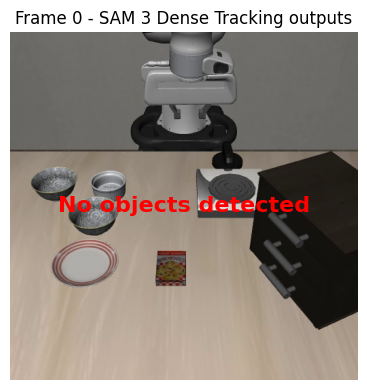

In [226]:
prompt_text_str = "nothing"
frame_idx = 0  # add a text prompt on frame 0
predictor.model.score_threshold_detection = 0.1
predictor.model.new_det_thresh = 0.2
response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=prompt_text_str,
    )
)
out = response["outputs"]
print(out['out_probs'])
plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
)

In [216]:
import networkx as nx

def extract_objects(image, out, object_type):
    # PIL size is (width, height)
    img_W, img_H = image.size

    obj_map = {}
    for obj_id, box_xywh, mask, score in zip(out['out_obj_ids'], out['out_boxes_xywh'], out['out_binary_masks'], out['out_probs']):
        p1 = box_xywh[:2]
        p2 = box_xywh[2:] + p1
        # NOT matrix multiplication. Multiplies first column by img_W and second column by img_H
        box_pixel = np.array([p1, p2]) * np.array([img_W, img_H])
        crop = image.crop(box_pixel.flatten())
        obj_map[obj_id] = {
            'box': box_pixel,
            'box_xywh': box_xywh,
            'crop': crop,
            'mask': mask,
            'sam3_score': score
        }
    return obj_map


In [217]:
import time

image = video_data[0]

llm_out = [
"light brown wooden surface | the main surface everything is on",
"dark brown cabinet with three drawers | on the right side of the table",
"small, single electric stove burner | on the table, left of the drawer cabinet",
"dark, textured bowl with a gold rim | on the left side of the table",
"small, silver-colored ramekin | on the table, between the two textured bowls",
"dark, textured bowl with a gold rim | on the table, below textured_bowl_1",
"white plate with a red striped rim | on the table, in the foreground",
"small red and white box of cookies | on the table, in front of the stove"
]
texts = ['a ' + s.replace(' | ', ' ') for s in llm_out]
all_objects = ['a ' + s.split('|')[0].strip() for s in llm_out]

t0 = time.monotonic()
all_tracks = {}
for class_id, text in enumerate(texts):
    _ = predictor.handle_request(
        request=dict(
            type="reset_session",
            session_id=session_id,
        )
    )
    predictor.model.score_threshold_detection = 0.1
    predictor.model.new_det_thresh = 0.2
    frame_idx = 0  # add a text prompt on frame 0
    response = predictor.handle_request(
        request=dict(
            type="add_prompt",
            session_id=session_id,
            frame_index=frame_idx,
            text=text,
        )
    )
    predictor.model.score_threshold_detection = 0.5
    predictor.model.new_det_thresh = 0.7
    out = response["outputs"]
    obj_id = text[2:].replace(' ', '_')
    objects = extract_objects(image, out, obj_id)
    for _id, obj in objects.items():
        # Deduplicate greedily
        obj['obj_id'] = f"{obj_id}_{_id}"
        score_vec = np.zeros(len(texts))
        score_vec[class_id] = obj['sam3_score']
        obj['sam3_score'] = score_vec
        self_mask = obj['mask']
        reject = False
        tracks = list(all_tracks.values())
        for track in tracks:
            other_mask = track['mask']
            intersection = np.sum(self_mask * other_mask)
            union = np.sum((self_mask + other_mask) != 0)
            if intersection/union > 0.9:
                if score_vec[class_id] > np.max(track['sam3_score']):
                    del all_tracks[track['obj_id']]
                    obj['sam3_score'] += track['sam3_score']
                else:
                    reject = True
                    track['sam3_score'] += score_vec
                    break
        if not reject:
            all_tracks[obj['obj_id']] = obj

print(all_tracks)
print(len(all_tracks), "tracks.")
t1 = time.monotonic()

G = nx.Graph()
for i, obj_ref in enumerate(all_objects):
    G.add_node(i, bipartite=1)

with torch.no_grad():
    tracks = list(all_tracks.values())
    all_images = [track['crop'] for track in tracks]
    inputs = clip_processor(text=texts, images=all_images, padding="max_length", return_tensors="pt")
    outputs = clip_model(**inputs)    
    logits_per_image = outputs.logits_per_image
    probs = torch.sigmoid(logits_per_image) # these are the probabilities
    for j, track in enumerate(tracks):
        G.add_node(track['obj_id'], bipartite=0)
        for i, obj_ref in enumerate(all_objects):
            #print(i, track['obj_id'], probs[j][obj_ref])
            G.add_edge(track['obj_id'], i, weight=0.0*float(probs[j][i]) + 0.5*track['sam3_score'][i])
t2 = time.monotonic()
print(f"Time elapsed: {t1 - t0} segment, {t2 - t1} ground, {t2 - t0} total")

{'light_brown_wooden_surface_the_main_surface_everything_is_on_0': {'box': array([[  0., 176.],
       [511., 511.]]), 'box_xywh': array([0.       , 0.34375  , 0.9980469, 0.6542969], dtype=float32), 'crop': <PIL.Image.Image image mode=RGB size=511x335 at 0x7F686C28D4F0>, 'mask': array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]]), 'sam3_score': array([0.96097565, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ]), 'obj_id': 'light_brown_wooden_surface_the_main_surface_everything_is_on_0'}, 'dark_brown_cabinet_with_three_drawers_on_the_right_side_of_the_table_0': {'box': array([[353., 176.],
       [511., 436.]]), 'box_xywh': array([0.6894531 , 0.34375   

{7: 'small_red_and_white_box_of_cookies_on_the_table,_in_front_of_the_stove_0', 2: 'small,_single_electric_stove_burner_on_the_table,_left_of_the_drawer_cabinet_1', 3: 'dark,_textured_bowl_with_a_gold_rim_on_the_left_side_of_the_table_2', 4: 'small,_silver-colored_ramekin_on_the_table,_between_the_two_textured_bowls_2', 5: 'dark,_textured_bowl_with_a_gold_rim_on_the_left_side_of_the_table_0', 6: 'white_plate_with_a_red_striped_rim_on_the_table,_in_the_foreground_0', 0: 'light_brown_wooden_surface_the_main_surface_everything_is_on_0', 1: 'dark_brown_cabinet_with_three_drawers_on_the_right_side_of_the_table_0'}
0 a light brown wooden surface the main surface everything is on
1 a dark brown cabinet with three drawers on the right side of the table
2 a small, single electric stove burner on the table, left of the drawer cabinet
3 a dark, textured bowl with a gold rim on the left side of the table
4 a small, silver-colored ramekin on the table, between the two textured bowls
5 a dark, textu

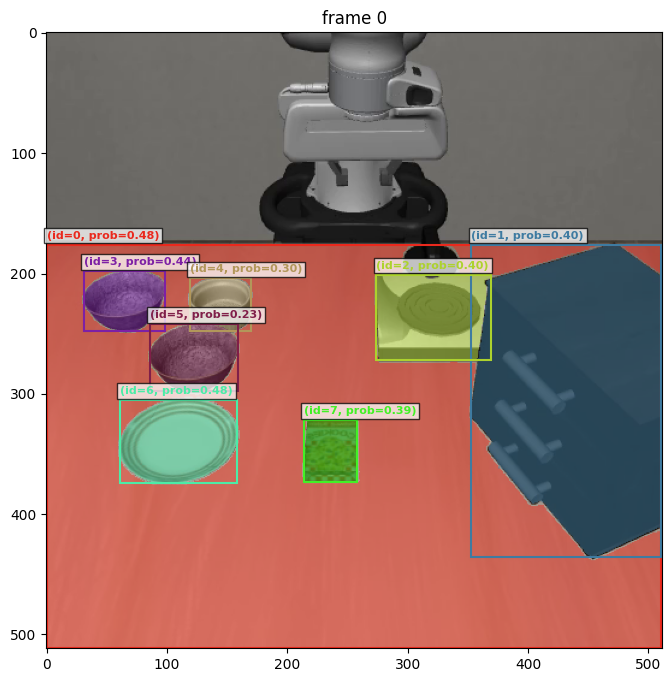

In [218]:
matching = nx.max_weight_matching(G, maxcardinality=True)
matching = dict(x if (type(x[0]) == int) else x[::-1] for x in matching)
print(matching)
output_maps = {
    'out_boxes_xywh': [],
    'out_probs': [],
    'out_obj_ids': [],
    'out_binary_masks': [],
}
for i in range(len(all_objects)):
    track_name = matching[i]
    obj = all_tracks[track_name]
    print(i, texts[i])
    output_maps['out_boxes_xywh'].append(obj['box_xywh'])
    output_maps['out_probs'].append(G[i][track_name]['weight'])
    output_maps['out_obj_ids'].append(i)
    output_maps['out_binary_masks'].append(obj['mask'])
visualize_frame_output(0, video_frames_for_vis, output_maps)

In [197]:
print(len(outputs['text_embeds']))

7


In [227]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

propagate_in_video:   0%|          | 0/20 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

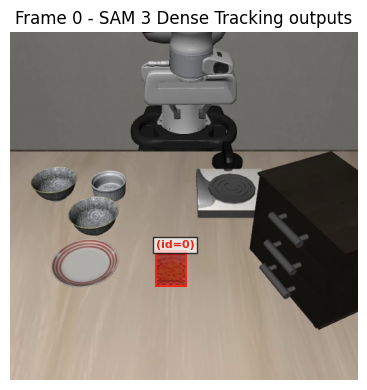

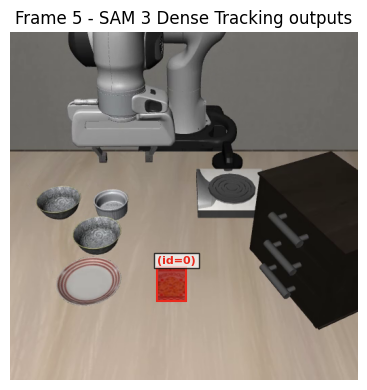

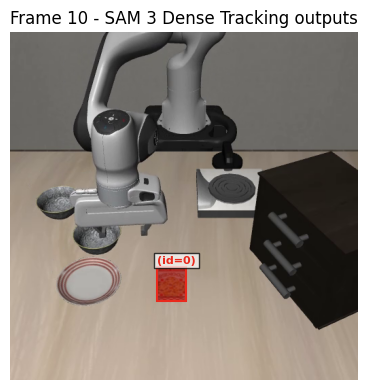

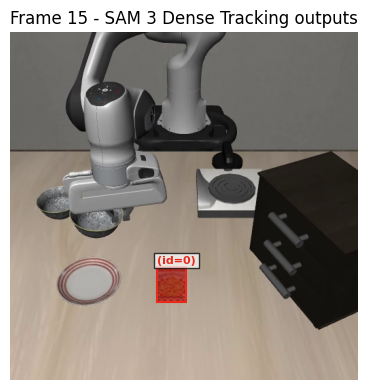

In [220]:
vis_frame_stride = 5
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

###  Removing objects

We can remove individual objects using their id.

As an example, let's remove object 2 (which is the dancer in the front).

In [ ]:
# we pick id 2, which is the dancer in the front
obj_id = 2
response = predictor.handle_request(
    request=dict(
        type="remove_object",
        session_id=session_id,
        obj_id=obj_id,
    )
)

In [ ]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

### Adding new objects with point prompts

We can add new objects through point prompts.

Assuming that we've changed our mind, and now that we want to add back the dancer in the front (whom we just removed in the step above). We can use interactive clicks to add her back.

In [221]:
sample_img = Image.fromarray(load_frame(video_frames_for_vis[0]))

IMG_WIDTH, IMG_HEIGHT = sample_img.size

In [228]:
# let's add back the dancer via point prompts.
# we will use a single positive click to add the dancer back.

frame_idx = 0

def mask_to_points(mask, n_sample=4):
    indices = np.argwhere(mask)[:, ::-1]
    sample = np.random.choice(len(indices), n_sample, replace=False)
    return indices[sample]

point_requests = []
for obj_id in range(len(all_objects)):
    track_name = matching[obj_id]
    obj = all_tracks[track_name]
    print(obj_id, texts[obj_id])
    points_abs = mask_to_points(obj['mask'])
    point_requests.append((obj_id, points_abs))

frame_idx = 0

obj_id = len(point_requests)
points_abs = np.array(
    [
        [255, 90],  # positive click
    ]
)
point_requests.append((obj_id, points_abs))

0 a light brown wooden surface the main surface everything is on
1 a dark brown cabinet with three drawers on the right side of the table
2 a small, single electric stove burner on the table, left of the drawer cabinet
3 a dark, textured bowl with a gold rim on the left side of the table
4 a small, silver-colored ramekin on the table, between the two textured bowls
5 a dark, textured bowl with a gold rim on the table, below textured_bowl_1
6 a white plate with a red striped rim on the table, in the foreground
7 a small red and white box of cookies on the table, in front of the stove


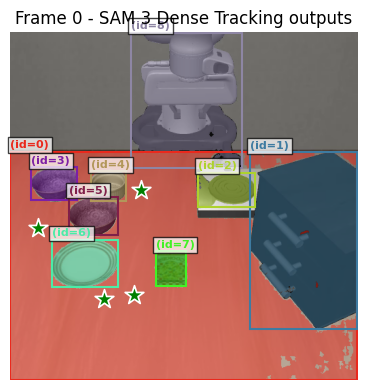

In [229]:
# convert points and labels to tensors; also convert to relative coordinates
# _ = predictor.handle_request(
#     request=dict(
#         type="reset_session",
#         session_id=session_id,
#     )
# )
img_W, img_H = image.size
for obj_id, points in point_requests:
    points_tensor = torch.tensor(
        abs_to_rel_coords(points, img_W, img_H, coord_type="point"),
        dtype=torch.float32,
    )
    points_labels_tensor = torch.tensor(np.ones(len(points)), dtype=torch.int32)
    response = predictor.handle_request(
        request=dict(
            type="add_prompt",
            session_id=session_id,
            frame_index=frame_idx,
            points=points_tensor,
            point_labels=points_labels_tensor,
            obj_id=obj_id,
        )
    )
    out = response["outputs"]
    #print(out)

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
    points_list=[req[1] for req in point_requests],
    points_labels_list=[np.ones(len(req[1])) for req in point_requests],
)

  0%|          | 0/20 [00:00<?, ?it/s]

0it [00:00, ?it/s]

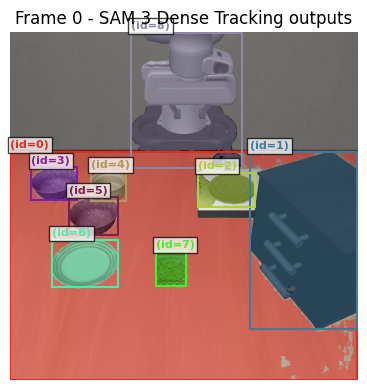

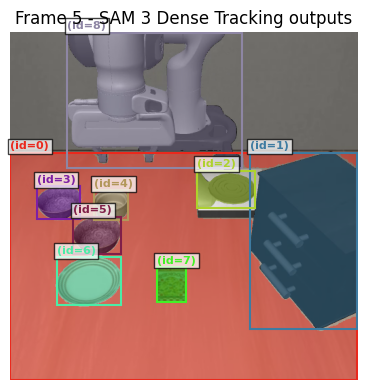

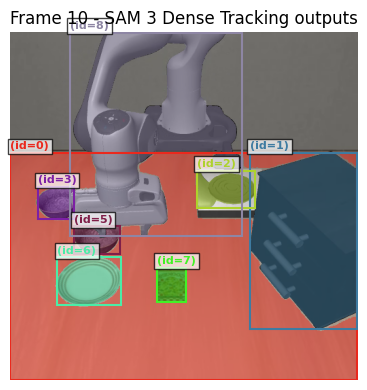

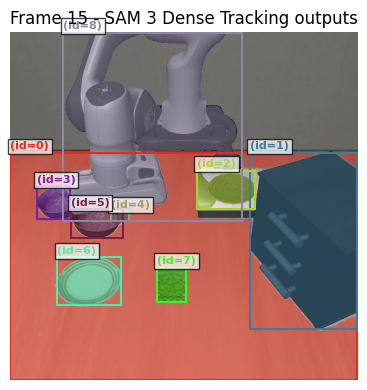

In [230]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 5
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

### Refining an existing object with point prompts

We can also refine the segmentation mask of an existing object through point prompts.

Assuming that we've changed our mind (again) -- for Object ID 2 (the dancer in the front whom we just added back in the step above), now we only want to segment her T-shirt instead of her whole body. We can adjust the segmentation mask with a few more positive and negative clicks.

In [ ]:
# For the dancer in the front, suppose now we only want to segment her T-shirt instead of her whole body
# we will use 2 positive clicks and 2 negative clicks to select her shirt.

frame_idx = 0
obj_id = 2
points_abs = np.array(
    [
        [740, 450],  # positive click
        [760, 630],  # negative click
        [840, 640],  # negative click
        [760, 550],  # positive click
    ]
)
# positive clicks have label 1, while negative clicks have label 0
labels = np.array([1, 0, 0, 1])

In [ ]:
# convert points and labels to tensors; also convert to relative coordinates
points_tensor = torch.tensor(
    abs_to_rel_coords(points_abs, IMG_WIDTH, IMG_HEIGHT, coord_type="point"),
    dtype=torch.float32,
)
points_labels_tensor = torch.tensor(labels, dtype=torch.int32)

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        points=points_tensor,
        point_labels=points_labels_tensor,
        obj_id=obj_id,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
    points_list=[points_abs],
    points_labels_list=[labels],
)

In [ ]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

### Close session

Each session is tied to a single video. We can close the session after inference to free up its resources.

(Then, you may start a new session on another video.)

In [13]:
# finally, close the inference session to free its GPU resources
# (you may start a new session on another video)
_ = predictor.handle_request(
    request=dict(
        type="close_session",
        session_id=session_id,
    )
)

INFO 2026-02-20 18:24:03,966 2747195 sam3_video_predictor.py: 251: removed session 24c4e526-4cf1-4b9f-abb4-661e0363b922; live sessions: [], GPU memory: 5108 MiB used and 7514 MiB reserved (max over time: 7030 MiB used and 7514 MiB reserved)


### Clean-up

After all inference is done, we can shutdown the predictor to free up the multi-GPU process group.

In [ ]:
# after all inference is done, we can shutdown the predictor
# to free up the multi-GPU process group
predictor.shutdown()